# HMS v15 — yamash-style 2D Raw-EEG Image + ConvNeXt Atto + Entmax

**Changes from v14 (based on Team Sony 1st-place yamash approach):**
- **Model**: Raw bipolar EEG → multi-crop 2D image (2000, 5000, 10000 samples) → resize & concat → 2D CNN
- **Backbone**: `convnext_atto.d2_in1k` via timm (easy swap to `inception_next_tiny`)
- **Output**: Entmax (α≈1.03) replaces softmax for crisper probability distributions
- **Channels**: 18 bipolar channels (16 standard + Fz-Cz, Cz-Pz)
- **Kept from v14**: `confident_train.csv`, data augmentation, KL loss, training loop, fold strategy

# Imports

In [14]:
import os, math, random, gc
from pathlib import Path
from typing import Callable, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import timm
from sklearn.model_selection import StratifiedGroupKFold
from scipy.signal import butter, sosfiltfilt
from scipy.ndimage import zoom as scipy_zoom
import joblib

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128, CUDA: True
GPU: Tesla T4


# Entmax Implementation (α-entmax via bisection)

In [15]:
# ---------- entmax_bisect: sparse softmax alternative ----------
# Adapted from https://github.com/deep-spin/entmax
# Supports arbitrary alpha > 1.0 via bisection algorithm.

def _entmax_bisect_forward(x, alpha, dim=-1, n_iter=50):
    """Compute α-entmax via bisection (forward pass).
    alpha=1.0 → softmax, alpha=1.5 → entmax15, alpha=2.0 → sparsemax.
    Team Sony used alpha≈1.03 for slightly crisper outputs.
    """
    alpha = float(alpha)
    if alpha == 1.0:
        return torch.softmax(x, dim=dim)

    d = x.shape[dim]
    x = x * (alpha - 1)

    max_val = x.max(dim=dim, keepdim=True).values
    x = x - max_val

    # Bisection to find threshold tau
    lo = torch.full_like(max_val, -1e4)
    hi = max_val.clone().squeeze(dim).unsqueeze(dim)  # ensure broadcastable
    hi = torch.full_like(max_val, 1e4)

    for _ in range(n_iter):
        tau = (lo + hi) / 2
        p = torch.clamp(x - tau, min=0) ** (1.0 / (alpha - 1))
        f = p.sum(dim=dim, keepdim=True) - 1.0
        lo = torch.where(f > 0, tau, lo)
        hi = torch.where(f > 0, hi, tau)

    tau = (lo + hi) / 2
    p = torch.clamp(x - tau, min=0) ** (1.0 / (alpha - 1))
    # Normalize to ensure sums to 1
    p = p / (p.sum(dim=dim, keepdim=True) + 1e-10)
    return p


class EntmaxBisect(nn.Module):
    """Drop-in replacement for softmax output layer using α-entmax.
    
    Args:
        alpha: entmax alpha parameter. 1.0=softmax, 1.5=entmax15, 2.0=sparsemax.
               Team Sony used ~1.03 for slightly crisper (but not truly sparse) outputs.
        dim: dimension along which to apply entmax.
    """
    def __init__(self, alpha=1.03, dim=-1, n_iter=50):
        super().__init__()
        self.alpha = alpha
        self.dim = dim
        self.n_iter = n_iter

    def forward(self, x):
        return _entmax_bisect_forward(x, self.alpha, self.dim, self.n_iter)

    def extra_repr(self):
        return f"alpha={self.alpha}, dim={self.dim}"


# Quick test
x_test = torch.tensor([[2.0, 1.0, 0.1, -0.5, 0.0, 0.3]])
entmax_fn = EntmaxBisect(alpha=1.03)
p_entmax = entmax_fn(x_test)
p_softmax = F.softmax(x_test, dim=-1)
print(f"Softmax:  {p_softmax.numpy().round(4)}, sum={p_softmax.sum().item():.4f}")
print(f"Entmax:   {p_entmax.numpy().round(4)}, sum={p_entmax.sum().item():.4f}")
print(f"Entmax makes outputs slightly crisper (closer to 0 for unlikely classes)")

Softmax:  [[0.5215 0.1918 0.078  0.0428 0.0706 0.0953]], sum=1.0000
Entmax:   [[0.5396 0.1918 0.0735 0.0381 0.0659 0.0911]], sum=1.0000
Entmax makes outputs slightly crisper (closer to 0 for unlikely classes)


# Data Augmentation

In [16]:
from __future__ import annotations

from typing import Callable, List, Tuple

import numpy as np
import torch


def _cfg_float(cfg, name: str, default: float) -> float:
    return float(getattr(cfg, name, default))

def _cfg_int(cfg, name: str, default: int) -> int:
    return int(getattr(cfg, name, default))

def _cfg_bool(cfg, name: str, default: bool) -> bool:
    return bool(getattr(cfg, name, default))


def apply_time_shift(x: np.ndarray, shift: int) -> np.ndarray:
    if shift == 0:
        return x
    out = np.zeros_like(x)
    if shift > 0:
        out[:, shift:] = x[:, :-shift]
    else:
        out[:, :shift] = x[:, -shift:]
    return out


def augment_sample_np(x: np.ndarray, cfg, target_sample_rate: int) -> np.ndarray:
    noise_std_min = _cfg_float(cfg, 'aug_noise_std_min', 0.0015)
    noise_std_max = _cfg_float(cfg, 'aug_noise_std_max', 0.0060)
    scale_min = _cfg_float(cfg, 'aug_scale_min', 0.93)
    scale_max = _cfg_float(cfg, 'aug_scale_max', 1.07)
    max_shift_seconds = _cfg_float(cfg, 'aug_max_shift_seconds', 0.25)

    if noise_std_max > 0:
        noise_std = np.random.uniform(noise_std_min, noise_std_max)
        x = x + np.random.normal(0.0, noise_std, size=x.shape).astype(np.float32)

    if scale_max > 0:
        scale = np.random.uniform(scale_min, scale_max)
        x = x * scale

    max_shift = max(0, int(round(max_shift_seconds * float(target_sample_rate))))
    if max_shift > 0:
        shift = np.random.randint(-max_shift, max_shift + 1)
        x = apply_time_shift(x, shift)

    return x.astype(np.float32)


def apply_mixup_batch(x, y, votes, cfg):
    use_mixup = _cfg_bool(cfg, 'use_mixup', True)
    mixup_prob = _cfg_float(cfg, 'mixup_prob', 0.60)
    mixup_alpha = _cfg_float(cfg, 'mixup_alpha', 0.40)

    bsz = int(x.shape[0])
    if not use_mixup or bsz < 2 or mixup_prob <= 0.0:
        return x, y, votes
    if np.random.rand() > mixup_prob:
        return x, y, votes

    alpha = max(mixup_alpha, 1e-6)
    lam_np = np.random.beta(alpha, alpha, size=bsz).astype(np.float32)
    perm = torch.randperm(bsz, device=x.device)
    lam = torch.tensor(lam_np, dtype=x.dtype, device=x.device)

    lam_x = lam.view(bsz, 1, 1)
    lam_y = lam.view(bsz, 1)

    x_mix = lam_x * x + (1.0 - lam_x) * x[perm]
    y_mix = lam_y * y + (1.0 - lam_y) * y[perm]

    votes_float = votes.to(dtype=x.dtype)
    votes_mix = lam * votes_float + (1.0 - lam) * votes_float[perm]
    votes_mix = votes_mix.to(dtype=votes.dtype)

    return x_mix, y_mix, votes_mix


def apply_time_mask_batch(x, cfg):
    prob = _cfg_float(cfg, 'time_mask_prob', 0.35)
    frac_min = _cfg_float(cfg, 'time_mask_frac_min', 0.03)
    frac_max = _cfg_float(cfg, 'time_mask_frac_max', 0.10)

    if prob <= 0.0:
        return x

    bsz, _channels, seq_len = x.shape
    min_len = max(1, int(round(frac_min * seq_len)))
    max_len = max(min_len, int(round(frac_max * seq_len)))

    for i in range(bsz):
        if np.random.rand() > prob:
            continue
        span = np.random.randint(min_len, max_len + 1)
        if span >= seq_len:
            x[i, :, :] = 0
            continue
        start = np.random.randint(0, seq_len - span + 1)
        x[i, :, start:start + span] = 0
    return x


def apply_channel_dropout_batch(x, cfg):
    prob = _cfg_float(cfg, 'channel_drop_prob', 0.25)
    max_drop = _cfg_int(cfg, 'channel_drop_max', 2)

    if prob <= 0.0 or max_drop <= 0:
        return x

    bsz, channels, _seq_len = x.shape
    max_drop = min(max_drop, channels)
    if max_drop <= 0:
        return x

    for i in range(bsz):
        if np.random.rand() > prob:
            continue
        n_drop = np.random.randint(1, max_drop + 1)
        drop_idx = np.random.choice(channels, size=n_drop, replace=False)
        x[i, drop_idx, :] = 0
    return x

# Configuration

In [17]:
class CFG:
    seed = 42
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Classes
    num_classes = 6
    class_names = ["Seizure", "LPD", "GPD", "LRDA", "GRDA", "Other"]
    name2label = {v: k for k, v in enumerate(class_names)}

    # EEG
    eeg_sample_rate = 200
    eeg_duration = 50
    eeg_samples = eeg_sample_rate * eeg_duration  # 10000
    num_bipolar_channels = 18  # Extended from 16 (added Fz-Cz, Cz-Pz)

    # Bandpass
    bandpass_low = 0.5
    bandpass_high = 20.0
    bandpass_order = 4

    # ── yamash-style 2D image approach ──
    # Crop intervals (in samples) from center of the 10000-sample window
    crop_lengths = [2000, 5000, 10000]  # ~10s, 25s, 50s at 200Hz
    image_height = 128  # Resize height for each crop (channels dimension)
    image_width = 512   # Resize width for each crop (time dimension)
    # Final image: [3, 18 * image_height_per_channel, image_width]
    # Actually: stack 3 crops as 3 channels → [3, 18, image_width] → reshape

    # Backbone (yamash approach)
    # Options: "convnext_atto.d2_in1k", "inception_next_tiny"
    backbone = "inception_next_tiny"
    dropout = 0.35

    # Entmax (Team Sony: alpha ≈ 1.03 for slightly crisper outputs)
    entmax_alpha = 1.03

    # Training
    epochs = 25
    batch_size = 48
    use_amp = False
    max_grad_norm = 1.0
    num_workers = 4
    n_folds = 5
    run_folds = [0, 1, 2, 3, 4]

    # Learning rates
    lr_head = 3e-4
    lr_backbone = 1e-5
    warmup_epochs = 1

    # Data
    use_soft_labels = True
    label_smoothing = 0.

    # Per-sample augmentation (data_aug)
    aug_noise_std_min = 0.0015
    aug_noise_std_max = 0.01
    aug_scale_min = 0.93
    aug_scale_max = 1.07
    aug_max_shift_seconds = 0.25

    # Batch-level augmentation (data_aug)
    use_mixup = True
    mixup_prob = 0.85
    mixup_alpha = 0.5
    time_mask_prob = 0.5
    time_mask_frac_min = 0.03
    time_mask_frac_max = 0.15
    channel_drop_prob = 0.35
    channel_drop_max = 4

# Print summary
print(f"Backbone: {CFG.backbone}")
print(f"Entmax alpha: {CFG.entmax_alpha}")
print(f"Bipolar channels: {CFG.num_bipolar_channels}")
print(f"Crop lengths: {CFG.crop_lengths} samples")
print(f"Image target: [{CFG.num_bipolar_channels}, {CFG.image_width}] per crop, 3 crops as RGB channels")
print(f"Training: {CFG.epochs} epochs, batch={CFG.batch_size}, AMP={CFG.use_amp}")
print(f"LRs: head={CFG.lr_head}, backbone={CFG.lr_backbone}")
print(f"Augmentation: mixup_prob={CFG.mixup_prob}, mixup_alpha={CFG.mixup_alpha}")

Backbone: inception_next_tiny
Entmax alpha: 1.03
Bipolar channels: 18
Crop lengths: [2000, 5000, 10000] samples
Image target: [18, 512] per crop, 3 crops as RGB channels
Training: 25 epochs, batch=48, AMP=False
LRs: head=0.0003, backbone=1e-05
Augmentation: mixup_prob=0.85, mixup_alpha=0.5


In [18]:
def set_seed(seed=CFG.seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

# Paths

In [19]:
project_root = Path.cwd()
BASE_PATH = project_root.parent.parent.parent / "data" / "data"

MODELS_DIR = project_root / "models"
RESULTS_DIR = project_root / "results"
PROCESSED_DIR = BASE_PATH / "processed" / "raw_eegs"
for d in [MODELS_DIR, RESULTS_DIR, PROCESSED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Data: {BASE_PATH} (exists={BASE_PATH.exists()})")
print(f"Processed EEGs: {PROCESSED_DIR}")

Data: /home/littl/data/data (exists=True)
Processed EEGs: /home/littl/data/data/processed/raw_eegs


# Load Data (confident_train.csv)

In [20]:
# Load pre-filtered confident train data
df = pd.read_csv(BASE_PATH / "confident_train.csv")
df["eeg_path"] = df["eeg_id"].apply(lambda x: str(BASE_PATH / "train_eegs" / f"{x}.parquet"))
df["class_name"] = df["expert_consensus"].copy()
df["class_label"] = df["expert_consensus"].map(CFG.name2label)

# Compute soft labels
vote_cols = ["seizure_vote", "lpd_vote", "gpd_vote", "lrda_vote", "grda_vote", "other_vote"]
votes = df[vote_cols].values.astype(np.float32)
vote_sums = votes.sum(axis=1, keepdims=True).clip(1.0)
soft_labels = votes / vote_sums
df["soft_labels"] = soft_labels.tolist()
df["total_votes"] = vote_sums.flatten().astype(int)
df["consensus"] = soft_labels.max(axis=1)

print(f"Train samples: {len(df)}")
print(f"Unique EEGs: {df['eeg_id'].nunique()}, Patients: {df['patient_id'].nunique()}")
print(f"Consensus: min={df['consensus'].min():.2f}, median={df['consensus'].median():.2f}, max={df['consensus'].max():.2f}")
print(f"\nClass distribution:")
print(df["class_name"].value_counts().to_string())

# Load confident test data (for evaluation after training)
confident_test_df = pd.read_csv(BASE_PATH / "confident_test.csv")
confident_test_df["eeg_path"] = confident_test_df["eeg_id"].apply(
    lambda x: str(BASE_PATH / "test_eegs" / f"{x}.parquet"))
if "expert_consensus" in confident_test_df.columns:
    confident_test_df["class_label"] = confident_test_df["expert_consensus"].map(CFG.name2label)
    test_vote_cols = [c for c in vote_cols if c in confident_test_df.columns]
    if test_vote_cols:
        test_votes = confident_test_df[test_vote_cols].values.astype(np.float32)
        test_vote_sums = test_votes.sum(axis=1, keepdims=True).clip(1.0)
        confident_test_df["soft_labels"] = (test_votes / test_vote_sums).tolist()
        confident_test_df["total_votes"] = test_vote_sums.flatten().astype(int)
        confident_test_df["consensus"] = (test_votes / test_vote_sums).max(axis=1)
print(f"\nConfident test samples: {len(confident_test_df)}")

Train samples: 61102
Unique EEGs: 11416, Patients: 1654
Consensus: min=0.70, median=1.00, max=1.00

Class distribution:
class_name
Seizure    16516
GRDA       12225
Other      10607
LPD         7841
GPD         7384
LRDA        6529

Confident test samples: 6621


# Bipolar Montage (18 channels)

In [21]:
BIPOLAR_MONTAGE = {
    "LL": [("Fp1","F7"), ("F7","T3"), ("T3","T5"), ("T5","O1")],
    "RL": [("Fp2","F8"), ("F8","T4"), ("T4","T6"), ("T6","O2")],
    "LP": [("Fp1","F3"), ("F3","C3"), ("C3","P3"), ("P3","O1")],
    "RP": [("Fp2","F4"), ("F4","C4"), ("C4","P4"), ("P4","O2")],
}
# Build standard 16 pairs
BIPOLAR_PAIRS = []
for chain in ["LL", "RL", "LP", "RP"]:
    BIPOLAR_PAIRS.extend(BIPOLAR_MONTAGE[chain])

# Add 2 midline cross-hemisphere pairs → 18 total
BIPOLAR_PAIRS.append(("Fz", "Cz"))
BIPOLAR_PAIRS.append(("Cz", "Pz"))

assert len(BIPOLAR_PAIRS) == 18, f"Expected 18 pairs, got {len(BIPOLAR_PAIRS)}"
print(f"Bipolar channels: {len(BIPOLAR_PAIRS)}")
for i, (a, b) in enumerate(BIPOLAR_PAIRS):
    print(f"  {i:2d}: {a} - {b}")

Bipolar channels: 18
   0: Fp1 - F7
   1: F7 - T3
   2: T3 - T5
   3: T5 - O1
   4: Fp2 - F8
   5: F8 - T4
   6: T4 - T6
   7: T6 - O2
   8: Fp1 - F3
   9: F3 - C3
  10: C3 - P3
  11: P3 - O1
  12: Fp2 - F4
  13: F4 - C4
  14: C4 - P4
  15: P4 - O2
  16: Fz - Cz
  17: Cz - Pz


# EEG Preprocessing

In [22]:
def bandpass_filter(data, low, high, fs, order=4):
    nyq = fs / 2.0
    sos = butter(order, [low / nyq, high / nyq], btype='band', output='sos')
    filtered = np.zeros_like(data)
    for i in range(data.shape[0]):
        if np.std(data[i]) > 1e-6:
            try:
                filtered[i] = sosfiltfilt(sos, data[i]).astype(np.float32)
            except ValueError:
                filtered[i] = data[i]
    return filtered


def preprocess_eeg(row_idx, dataframe, split="train"):
    row = dataframe.iloc[row_idx]
    eeg_id = row["eeg_id"]
    output_path = PROCESSED_DIR / f"{eeg_id}.npz"
    if output_path.exists():
        return

    eeg_df = pd.read_parquet(row["eeg_path"])
    offset = int(row.get("eeg_label_offset_seconds", 0))
    start = offset * CFG.eeg_sample_rate
    end = start + CFG.eeg_samples
    window = eeg_df.iloc[start:end]

    if len(window) < CFG.eeg_samples:
        pad = pd.DataFrame(np.zeros((CFG.eeg_samples - len(window), len(window.columns))),
                           columns=window.columns)
        window = pd.concat([window, pad], ignore_index=True)

    cols = window.columns.tolist()
    bipolar = []
    for (a, b) in BIPOLAR_PAIRS:
        sig = window[a].values - window[b].values if (a in cols and b in cols) else np.zeros(CFG.eeg_samples, dtype=np.float32)
        bipolar.append(sig)
    bipolar = np.stack(bipolar, axis=0).astype(np.float32)  # [18, 10000]
    bipolar = np.nan_to_num(bipolar, nan=0.0)
    bipolar = np.clip(bipolar, -1024, 1024)
    bipolar = bandpass_filter(bipolar, CFG.bandpass_low, CFG.bandpass_high,
                              CFG.eeg_sample_rate, CFG.bandpass_order)

    chan_mean = bipolar.mean(axis=1).astype(np.float32)
    chan_std = bipolar.std(axis=1).astype(np.float32)
    stats = np.concatenate([chan_mean, chan_std])  # [36] now (18*2)
    bipolar = (bipolar - chan_mean[:, None]) / (chan_std[:, None] + 1e-6)
    np.savez_compressed(str(output_path), eeg=bipolar, stats=stats)


# Uncomment to run preprocessing:
# unique_train = df.drop_duplicates(subset="eeg_id").reset_index(drop=True)
# print(f"Processing {len(unique_train)} train EEGs...")
# _ = joblib.Parallel(n_jobs=-1, backend="loky")(
#     joblib.delayed(preprocess_eeg)(i, unique_train) for i in tqdm(range(len(unique_train))))
# unique_test = confident_test_df.drop_duplicates(subset="eeg_id").reset_index(drop=True)
# print(f"Processing {len(unique_test)} test EEGs...")
# _ = joblib.Parallel(n_jobs=-1, backend="loky")(
#     joblib.delayed(preprocess_eeg)(i, unique_test, "test") for i in tqdm(range(len(unique_test))))
# print("Done.")

# Dataset

In [23]:
class HMSDataset(Dataset):
    """Dataset that uses data_aug for per-sample augmentation.
    Returns (eeg, stats, label, votes) for train, (eeg, stats) for test.
    Batch-level augmentation (mixup, time_mask, channel_drop) is applied
    in the training loop, not here.
    """
    def __init__(self, df, mode="train", augment=False):
        self.df = df.reset_index(drop=True)
        self.mode = mode
        self.augment = augment
        self.npz_paths = [str(PROCESSED_DIR / f"{eid}.npz") for eid in self.df["eeg_id"].values]
        self.total_votes = self.df["total_votes"].values.astype(np.float32) if "total_votes" in self.df.columns else np.ones(len(self.df), dtype=np.float32)
        self.consensus = self.df["consensus"].values.astype(np.float32) if "consensus" in self.df.columns else np.ones(len(self.df), dtype=np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        data = np.load(self.npz_paths[idx])
        eeg = data["eeg"]      # [18, 10000]
        stats = data["stats"]  # [36]

        # Per-sample augmentation (noise, scale, time shift)
        if self.augment:
            eeg = augment_sample_np(eeg, CFG, CFG.eeg_sample_rate)

        eeg_t = torch.tensor(eeg, dtype=torch.float32)
        stats_t = torch.tensor(stats, dtype=torch.float32)

        if self.mode == "test":
            return eeg_t, stats_t

        # Labels
        row = self.df.iloc[idx]
        if CFG.use_soft_labels and row.get("soft_labels") is not None:
            label = torch.tensor(np.array(row["soft_labels"], dtype=np.float32))
        else:
            label = torch.zeros(CFG.num_classes, dtype=torch.float32)
            label[int(row["class_label"])] = 1.0

        votes_t = torch.tensor(self.total_votes[idx], dtype=torch.float32)
        consensus_t = torch.tensor(self.consensus[idx], dtype=torch.float32)
        return eeg_t, stats_t, label, votes_t, consensus_t

# Model — yamash-style 2D Raw-EEG Image + ConvNeXt Atto

**Approach (from Team Sony 1st place, yamash's part):**
1. Take 18 bipolar-montage EEG signals (raw, time-domain)
2. Crop at 3 different intervals (2000, 5000, 10000 samples) centered on the window
3. Resize each crop to a common width → each becomes a [18, W] image
4. Stack the 3 crops as 3 RGB channels → [3, 18, W]
5. Feed through a 2D CNN backbone (ConvNeXt Atto)
6. Global average pool + classification head with **entmax** (α≈1.03) instead of softmax

In [24]:
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F

class YamashCNN_EEGModel(nn.Module):
    """yamash-style 2D image + ConvNeXt backbone + entmax (No GRU)."""
    
    def __init__(self, model_name=CFG.backbone, num_classes=6, hidden_dim=128):
        super().__init__()
        self.crop_lengths = CFG.crop_lengths      # [2000, 5000, 10000]
        self.target_width = CFG.image_width       # 512
        self.n_channels = CFG.num_bipolar_channels # 18
        
        # 1. Vision Backbone
        self.backbone = timm.create_model(
            model_name, pretrained=True, in_chans=3,
            features_only=True,
        )
        # Dynamically get the output channel dimension (e.g., 320 for Atto)
        cnn_out_dim = self.backbone.feature_info[-1]['num_chs']
        
        # 2. Classification Head
        # The input is now cnn_out_dim instead of the GRU's hidden size
        self.head = nn.Sequential(
            nn.Linear(cnn_out_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.65),
            nn.Linear(hidden_dim, num_classes)
        )
        
        # 3. Entmax output (replaces softmax)
        self.entmax_layer = EntmaxBisect(alpha=CFG.entmax_alpha, dim=-1)
        
        print(f"Model: backbone={model_name} ({cnn_out_dim}ch) → GAP → entmax(α={CFG.entmax_alpha})")

    def _make_multicrop_image(self, eeg):
        """Raw EEG [B, 18, 10000] → 2D image [B, 3, 128, W]."""
        B, C, T = eeg.shape
        crops = []
        for crop_len in self.crop_lengths:
            start = max(0, (T - crop_len) // 2)
            end = start + min(crop_len, T)
            crop = eeg[:, :, start:end]
            crop = F.interpolate(crop, size=self.target_width, mode='linear', align_corners=False)
            crops.append(crop)
        img = torch.stack(crops, dim=1)  # [B, 3, 18, W]
        # Upscale height for backbone
        img = F.interpolate(img, size=(128, self.target_width), mode='bilinear', align_corners=False)
        # Normalize
        img = (img - img.mean(dim=(2, 3), keepdim=True)) / (img.std(dim=(2, 3), keepdim=True) + 1e-6)
        return img

    def forward(self, eeg, stats=None):
        """
        Args:
            eeg: [B, 18, 10000] raw bipolar EEG from dataloader
            stats: [B, 36] (accepted but not used — kept for dataloader compat)
        """
        # Build multi-crop image from raw EEG
        x = self._make_multicrop_image(eeg)  # [B, 3, 128, W]
        
        # CNN feature extraction
        x = self.backbone(x)[-1]  # [B, C_out, H', W']
        
        # Global Average Pooling (GAP)
        # Instantly collapses the spatial Height and Width into a single 1D vector
        x = x.mean(dim=[2, 3])    # [B, C_out]
        
        # Classify with entmax
        logits = self.head(x)
        out = self.entmax_layer(logits)
        
        # Clamp to avoid log(0) NaN loss in KL-Divergence
        return out.clamp(min=1e-8, max=1.0)

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def _entmax_bisect_optimized(x, alpha, dim=-1, n_iter=50):
    """
    Compute α-entmax via bisection, optimized for PyTorch VRAM.
    """
    alpha = float(alpha)
    if alpha == 1.0:
        return F.softmax(x, dim=dim)

    # Pre-scale x
    x_scaled = x * (alpha - 1)

    # 1. FIND TAU WITHOUT GRADIENTS (Saves massive VRAM & Time)
    with torch.no_grad():
        max_val = x_scaled.max(dim=dim, keepdim=True).values
        
        # Tighter logical bounds than -1e4 / 1e4
        lo = max_val - 1.0
        hi = max_val + 1000.0 

        for _ in range(n_iter):
            tau = (lo + hi) / 2
            p = torch.clamp(x_scaled - tau, min=0) ** (1.0 / (alpha - 1))
            f = p.sum(dim=dim, keepdim=True) - 1.0
            
            lo = torch.where(f > 0, tau, lo)
            hi = torch.where(f <= 0, tau, hi) # Fixed logic to strictly cut bounds
            
        tau = (lo + hi) / 2

    # 2. CALCULATE FINAL OUTPUT WITH GRADIENTS
    # We apply the discovered tau to the original attached tensor
    p = torch.clamp(x_scaled - tau, min=0) ** (1.0 / (alpha - 1))
    
    # Normalize to ensure sums to 1
    p = p / (p.sum(dim=dim, keepdim=True) + 1e-10)
    return p

class EntmaxBisect(nn.Module):
    def __init__(self, alpha=1.03, dim=-1, n_iter=50):
        super().__init__()
        self.alpha = alpha
        self.dim = dim
        self.n_iter = n_iter

    def forward(self, x):
        return _entmax_bisect_optimized(x, self.alpha, self.dim, self.n_iter)

# Quick test
x_test = torch.tensor([[2.0, 1.0, 0.1, -0.5, 0.0, 0.3]], requires_grad=True)
entmax_fn = EntmaxBisect(alpha=1.03)

p_entmax = entmax_fn(x_test)
p_softmax = F.softmax(x_test, dim=-1)

print(f"Softmax:  {p_softmax.detach().numpy().round(4)}, sum={p_softmax.sum().item():.4f}")
print(f"Entmax:   {p_entmax.detach().numpy().round(4)}, sum={p_entmax.sum().item():.4f}")

# Verify gradients flow smoothly without VRAM explosion
p_entmax.sum().backward()
print(f"Gradients computed successfully: {x_test.grad is not None}")

Softmax:  [[0.5215 0.1918 0.078  0.0428 0.0706 0.0953]], sum=1.0000
Entmax:   [[0.5396 0.1918 0.0735 0.0381 0.0659 0.0911]], sum=1.0000
Gradients computed successfully: True


# Sanity Check

In [26]:
import gc
import torch

model_cpu = YamashCNN_EEGModel(model_name=CFG.backbone)

with torch.no_grad():
    # Input matches what dataloader produces: [B, 18, 10000]
    dummy_eeg = torch.randn(2, CFG.num_bipolar_channels, CFG.eeg_samples)
    dummy_stats = torch.randn(2, CFG.num_bipolar_channels * 2)
    out = model_cpu(dummy_eeg, dummy_stats)
    
    print(f"Output: {out.shape}, prob sum: {out.sum(dim=1).numpy()}")
    print(f"Sample output: {out[0].numpy().round(4)}")
    print(f"Min prob: {out.min().item():.6f}")

total = sum(p.numel() for p in model_cpu.parameters())
print(f"Params: {total:,} ({sum(p.numel()*p.element_size() for p in model_cpu.parameters())/1e6:.1f} MB)")
del model_cpu; gc.collect()

Model: backbone=inception_next_tiny (768ch) → GAP → entmax(α=1.03)
Output: torch.Size([2, 6]), prob sum: [1.         0.99999994]
Sample output: [0.1515 0.143  0.2191 0.1603 0.1656 0.1606]
Min prob: 0.126495
Params: 24,073,502 (96.3 MB)


25

# Data Split

In [27]:
sgkf = StratifiedGroupKFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)
df["fold"] = -1
for fold, (_, val_idx) in enumerate(sgkf.split(df, y=df["class_label"], groups=df["patient_id"])):
    df.loc[val_idx, "fold"] = fold

sample_df = df.groupby("spectrogram_id").head(1).reset_index(drop=True)
print(f"Unique samples per fold: ~{len(sample_df) // CFG.n_folds}")
print(df.groupby(["fold", "class_name"])[["eeg_id"]].count().unstack())

Unique samples per fold: ~1504
           eeg_id                                
class_name    GPD  GRDA   LPD  LRDA Other Seizure
fold                                             
0            1818  3591  2380   557  2505    3142
1             658  1969   671  1484  1571    3033
2             849  2340  1489  1925  2134    3319
3            1848  2210  2061  1271  2182    3851
4            2211  2115  1240  1292  2215    3171


In [28]:
def build_fold_loaders(fold):
    train_data = sample_df[sample_df.fold != fold].reset_index(drop=True)
    valid_data = sample_df[sample_df.fold == fold].reset_index(drop=True)

    train_ds = HMSDataset(train_data, mode="train", augment=True)   # per-sample aug ON
    valid_ds = HMSDataset(valid_data, mode="valid", augment=False)   # no augmentation

    kw = dict(pin_memory=True, persistent_workers=CFG.num_workers > 0, num_workers=CFG.num_workers)
    train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True, drop_last=True, **kw)
    valid_loader = DataLoader(valid_ds, batch_size=CFG.batch_size, shuffle=False, drop_last=False, **kw)
    return train_loader, valid_loader, valid_data

train_loader, valid_loader, _ = build_fold_loaders(0)
print(f"Fold 0: {len(train_loader)} train / {len(valid_loader)} valid batches")

Fold 0: 121 train / 36 valid batches


# Loss, Optimizer & Scheduler

In [ ]:
class KLDivLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss_fn = nn.KLDivLoss(reduction="none")

    def forward(self, preds, targets, votes=None):
        per_sample = self.loss_fn(
            torch.log(preds.clamp(min=1e-8)), targets
        ).sum(dim=1)

        if votes is not None:
            weights = votes.clamp(min=1.0)
            weights = weights / weights.mean()
            return (per_sample * weights).mean()
        return per_sample.mean()

criterion = KLDivLoss()


def build_optimizer(model, cfg=CFG):
    """Separate LR for backbone vs head."""
    head_params = list(model.head.parameters())
    
    # Safely add GRU params only if the model actually has a GRU layer
    if hasattr(model, 'gru'):
        head_params += list(model.gru.parameters())
        head_name = "gru_head"
    else:
        head_name = "head"
        
    return torch.optim.AdamW([
        {"params": model.backbone.parameters(),
         "lr": cfg.lr_backbone, "weight_decay": 3e-2, "name": "backbone"},
        {"params": head_params,
         "lr": cfg.lr_head, "weight_decay": 3e-2, "name": head_name},
    ])

def get_cosine_schedule(optimizer, epochs, warmup_epochs=1):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / (warmup_epochs + 1)
        return 0.5 * (1 + math.cos(math.pi * (epoch - warmup_epochs) / (epochs - warmup_epochs)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Training & Validation

In [30]:
def train_one_epoch(model, loader, optimizer, criterion, device, epoch, total_epochs, cfg=CFG):
    """Train one epoch with batch-level augmentation from data_aug."""
    model.train()
    scaler = GradScaler(enabled=cfg.use_amp)
    running_loss, n = 0.0, 0

    pbar = tqdm(loader, desc=f"Train {epoch+1}/{total_epochs}")
    for eeg, stats, labels, votes, consensus in pbar:
        eeg = eeg.to(device, non_blocking=True)
        stats = stats.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        votes = votes.to(device, non_blocking=True)

        # Batch-level augmentation from data_aug module
        eeg, labels, votes = apply_mixup_batch(eeg, labels, votes, cfg)
        eeg = apply_time_mask_batch(eeg, cfg)
        eeg = apply_channel_dropout_batch(eeg, cfg)

        with autocast(enabled=cfg.use_amp):
            preds = model(eeg, stats)
            loss = criterion(preds, labels, votes=votes)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        n += 1
        pbar.set_postfix(loss=f"{running_loss/n:.4f}", gpu=f"{torch.cuda.memory_allocated()/1e9:.1f}G")

    return running_loss / n


@torch.no_grad()
def validate(model, loader, device, epoch, total_epochs, cfg=CFG):
    """Validate — no augmentation applied."""
    model.eval()
    all_losses, all_votes, all_consensus = [], [], []

    for eeg, stats, labels, votes, consensus in tqdm(loader, desc=f"Valid {epoch+1}/{total_epochs}"):
        eeg = eeg.to(device, non_blocking=True)
        stats = stats.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(enabled=cfg.use_amp):
            preds = model(eeg, stats)
            per_sample = nn.KLDivLoss(reduction="none")(
                torch.log(preds.clamp(min=1e-8)), labels
            ).sum(dim=1)

        all_losses.append(per_sample.cpu())
        all_votes.append(votes)
        all_consensus.append(consensus)

    all_losses = torch.cat(all_losses)
    all_votes = torch.cat(all_votes)
    all_consensus = torch.cat(all_consensus)

    hq = all_consensus >= 0.90

    val_all = all_losses.mean().item()
    val_hq = all_losses[hq].mean().item() if hq.any() else float("nan")
    print(f"  val_loss: ALL={val_all:.4f} | HQ(>=90%)={val_hq:.4f} ({hq.sum()}/{len(hq)})")
    return val_all, val_hq

# Training Loop

In [32]:
def train_fold(fold, cfg=CFG):
    print(f"\n{'='*60}\nFOLD {fold}\n{'='*60}")
    gc.collect(); torch.cuda.empty_cache()
    set_seed(cfg.seed + fold)

    # ---> THE FIX: Pass model_name explicitly instead of the whole cfg object
    model = YamashCNN_EEGModel(model_name=cfg.backbone).to(cfg.device)
    
    ckpt_path = str(MODELS_DIR / f"best_model_fold{fold}.pt")
    history = {"train_loss": [], "val_loss": [], "val_loss_hq": [], "lr": []}
    best_hq = float("inf")
    best_all = float("inf")
    best_epoch = -1

    train_loader, valid_loader, _ = build_fold_loaders(fold)
    optimizer = build_optimizer(model, cfg)
    scheduler = get_cosine_schedule(optimizer, cfg.epochs, cfg.warmup_epochs)

    for epoch in range(cfg.epochs):
        lrs = {pg["name"]: f"{pg['lr']:.1e}" for pg in optimizer.param_groups}
        print(f"\nEpoch {epoch+1}/{cfg.epochs} | LRs: {lrs}")

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion,
                                      cfg.device, epoch, cfg.epochs, cfg)
        val_all, val_hq = validate(model, valid_loader, cfg.device, epoch, cfg.epochs, cfg)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_all)
        history["val_loss_hq"].append(val_hq)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        # Save history every epoch
        torch.save(history, str(MODELS_DIR / f"history_v7_fold{fold}.pt"))

        if val_hq < best_hq:
            best_hq = val_hq
            best_all = val_all
            best_epoch = epoch
            torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                         "val_loss": val_all, "val_loss_hq": val_hq}, ckpt_path)
            print(f"  ✓ Saved (HQ={val_hq:.4f})")
        else:
            print(f"  best HQ={best_hq:.4f} @ epoch {best_epoch+1}")

    del model, optimizer, scheduler, train_loader, valid_loader
    gc.collect(); torch.cuda.empty_cache()
    print(f"\nFold {fold} done. Best HQ={best_hq:.4f}, ALL={best_all:.4f}")
    return {"all": best_all, "hq": best_hq}, history


# Run
fold_results, all_histories = {}, {}
for fold in CFG.run_folds:
    try:
        results, hist = train_fold(fold)
        fold_results[fold] = results
        all_histories[fold] = hist
    except RuntimeError as e:
        print(f"Fold {fold} failed: {e}")
        gc.collect(); torch.cuda.empty_cache()
        break

# Summary
print(f"\n{'='*60}\nCV RESULTS\n{'='*60}")
for fold, r in fold_results.items():
    print(f"  Fold {fold}: ALL={r['all']:.4f}, HQ={r['hq']:.4f}")
if fold_results:
    cv_hq = np.mean([r["hq"] for r in fold_results.values()])
    print(f"  Mean HQ: {cv_hq:.4f} (LB estimate)")


FOLD 0


Model: backbone=inception_next_tiny (768ch) → GAP → entmax(α=1.03)


AttributeError: 'YamashCNN_EEGModel' object has no attribute 'gru'

# Loss Curves

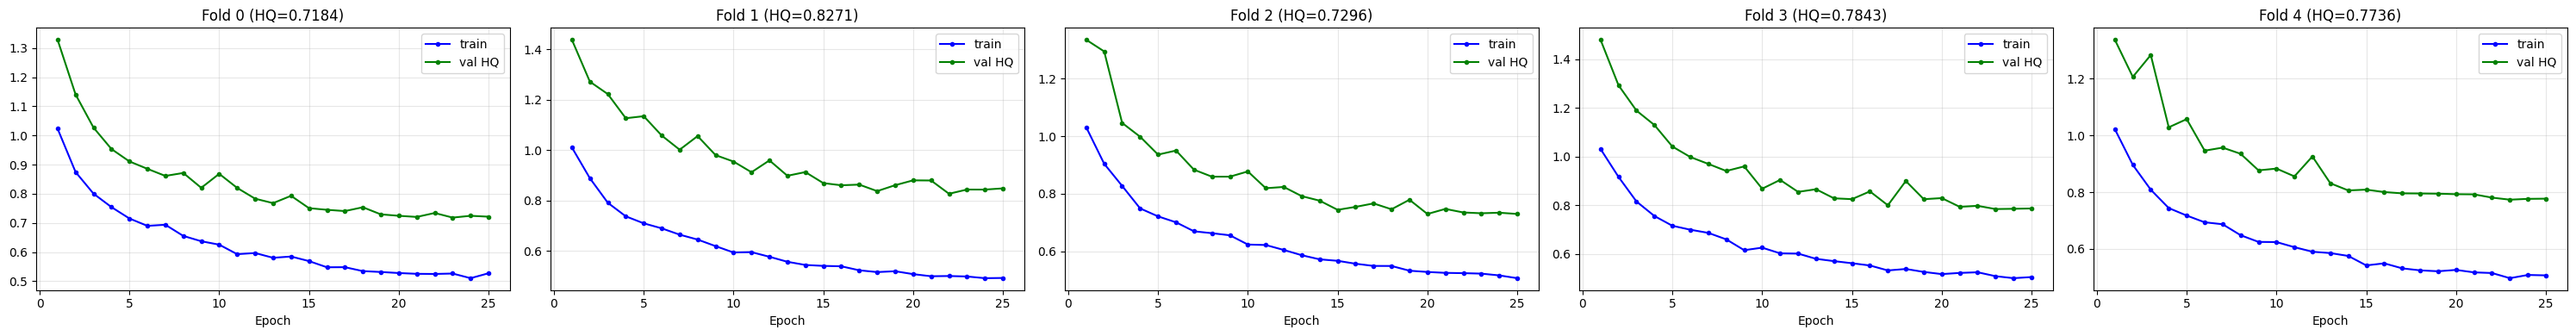

In [ ]:
n = len(all_histories)
if n == 0:
    print("No folds completed — skipping plots.")
else:
    fig, axes = plt.subplots(1, max(n, 1), figsize=(6*max(n, 1), 4))
    if n <= 1: axes = [axes]
    for ax, (fold, h) in zip(axes, all_histories.items()):
        ep = range(1, len(h["train_loss"])+1)
        ax.plot(ep, h["train_loss"], "b-o", ms=3, label="train")
        ax.plot(ep, h["val_loss_hq"], "g-o", ms=3, label="val HQ")
        ax.set_title(f"Fold {fold} (HQ={fold_results[fold]['hq']:.4f})")
        ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

# Test Evaluation (confident_test.csv)

In [ ]:
# Preprocess test EEGs if needed
# unique_test = confident_test_df.drop_duplicates(subset="eeg_id").reset_index(drop=True)
# print(f"Processing {len(unique_test)} test EEGs...")
# _ = joblib.Parallel(n_jobs=-1, backend="loky")(
#     joblib.delayed(preprocess_eeg)(i, unique_test, "test")
#     for i in tqdm(range(len(unique_test))))
# print("Done.")

# Build test loader
test_ds = HMSDataset(confident_test_df, mode="test")
test_loader = DataLoader(test_ds, batch_size=min(CFG.batch_size, len(confident_test_df)),
                          shuffle=False, num_workers=CFG.num_workers, pin_memory=True)

@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    preds = []
    for eeg, stats in tqdm(loader, desc="Predicting"):
        with autocast(enabled=CFG.use_amp):
            p = model(eeg.to(device), stats.to(device))
        preds.append(p.cpu().numpy())
    return np.concatenate(preds, axis=0)

# Predict with each fold's best model
all_preds = []
for fold in CFG.run_folds:
    ckpt_path = MODELS_DIR / f"best_model_v7_fold{fold}.pt"
    if not ckpt_path.exists():
        print(f"Fold {fold}: checkpoint not found, skipping")
        continue
    model = YamashCRNN_EEGModel(model_name=CFG.backbone).to(CFG.device)
    model.load_state_dict(torch.load(str(ckpt_path), map_location=CFG.device)["model_state_dict"])
    all_preds.append(predict(model, test_loader, CFG.device))
    print(f"Fold {fold}: done")
    del model; gc.collect(); torch.cuda.empty_cache()

preds = np.mean(all_preds, axis=0)
preds = preds / preds.sum(axis=1, keepdims=True)
print(f"\nEnsemble: {len(all_preds)} folds, shape={preds.shape}")

# Evaluate against confident_test labels if available
if "soft_labels" in confident_test_df.columns:
    targets = np.array(confident_test_df["soft_labels"].tolist(), dtype=np.float64)
    kl = (targets * np.log(targets.clip(1e-8) / preds.clip(1e-8))).sum(axis=1)
    print(f"\nTest KL Divergence:")
    print(f"  ALL: {kl.mean():.4f}")
    if "consensus" in confident_test_df.columns:
        consensus = confident_test_df["consensus"].values
        hq_mask = consensus >= 0.90
        if hq_mask.any():
            print(f"  HQ (>=90%): {kl[hq_mask].mean():.4f} ({hq_mask.sum()}/{len(hq_mask)})")
else:
    print("No test labels available for evaluation.")

Model: backbone=convnext_atto.d2_in1k (320ch) → GRU(128x2 bidir) → entmax(α=1.03)


Predicting:   0%|          | 0/138 [00:00<?, ?it/s]

/var/tmp/ipykernel_283169/2552431038.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.use_amp):


Fold 0: done
Model: backbone=convnext_atto.d2_in1k (320ch) → GRU(128x2 bidir) → entmax(α=1.03)


Predicting:   0%|          | 0/138 [00:00<?, ?it/s]

...

Model: backbone=convnext_atto.d2_in1k (320ch) → GRU(128x2 bidir) → entmax(α=1.03)


Predicting:   0%|          | 0/138 [00:00<?, ?it/s]

Fold 3: done
Model: backbone=convnext_atto.d2_in1k (320ch) → GRU(128x2 bidir) → entmax(α=1.03)


Predicting:   0%|          | 0/138 [00:00<?, ?it/s]

Fold 4: done

Ensemble: 5 folds, shape=(6621, 6)

Test KL Divergence:
  ALL: 0.8681
  HQ (>=90%): 0.8943 (6064/6621)


# Submission

In [ ]:
target_cols = [x.lower() + "_vote" for x in CFG.class_names]
pred_df = confident_test_df[["eeg_id"]].copy()
pred_df[target_cols] = preds.tolist()

sub_path = str(RESULTS_DIR / "submission.csv")
pred_df.to_csv(sub_path, index=False)
print(f"Saved: {sub_path} ({len(pred_df)} rows)")
print(pred_df.head())

Saved: /home/littl/ECE247A_Final_Project/AL/AL_model/results/submission.csv (6621 rows)
       eeg_id  seizure_vote  lpd_vote  gpd_vote  lrda_vote  grda_vote  \
0  4245882082      0.105847  0.018422  0.012053   0.086671   0.600356   
1  2857590162      0.257066  0.268339  0.041056   0.113392   0.084972   
2  2857590162      0.257066  0.268339  0.041056   0.113392   0.084972   
3  2857590162      0.257066  0.268339  0.041056   0.113392   0.084972   
4  3523834378      0.739941  0.010747  0.020732   0.013748   0.029745   

   other_vote  
0    0.176652  
1    0.235175  
2    0.235175  
3    0.235175  
4    0.185087  


# Notes: Extending to Full yamash Ensemble

To reproduce the full Team Sony yamash approach:

1. **Multiple backbones**: Change `CFG.backbone` to train with different architectures:
   - `"convnext_atto.d2_in1k"` (4 models, different seeds + bandpass filters)
   - `"inception_next_tiny"` (1 model)

2. **Different bandpass filters**: For each ConvNeXt Atto model, vary `CFG.bandpass_low` and `CFG.bandpass_high`

3. **Non-negative linear regression ensemble**: 
   ```python
   from sklearn.linear_model import Ridge
   # For each target, fit: y_target = w1*pred1 + w2*pred2 + ... (w >= 0)
   from scipy.optimize import nnls
   for col in range(6):
       w, _ = nnls(all_model_preds[:, :, col], targets[:, col])
       ensemble[:, col] = all_model_preds[:, :, col] @ w
   ```

4. **Entmax alpha tuning**: Try alpha in [1.01, 1.05] range. Higher = sparser outputs.